In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    classification_report
)

In [2]:
file_path = "/Users/maggie/Downloads/churn-bigml-80 (3).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts())

df.head()

Dataset shape: (2666, 20)

Churn distribution:
Churn
False    2278
True      388
Name: count, dtype: int64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Fix data types
if "State" in df.columns:
    df["State"] = df["State"].astype("category")

if "Area code" in df.columns:
    df["Area code"] = df["Area code"].astype(str).astype("category")

if "International plan" in df.columns:
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})

if "Voice mail plan" in df.columns:
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})

# Feature engineering
df_fe = df.copy()
df_fe = df_fe.drop(columns=["State", "Area code"], errors="ignore")

df_fe["total_minutes"] = (
    df_fe["Total day minutes"] +
    df_fe["Total eve minutes"] +
    df_fe["Total night minutes"] +
    df_fe["Total intl minutes"]
)

df_fe["total_charges"] = (
    df_fe["Total day charge"] +
    df_fe["Total eve charge"] +
    df_fe["Total night charge"] +
    df_fe["Total intl charge"]
)

df_fe["high_service_calls"] = (df_fe["Customer service calls"] >= 3).astype(int)

df_fe["intl_usage_ratio"] = (
    df_fe["Total intl minutes"] / df_fe["total_minutes"]
).fillna(0)

df_fe["account_length_group"] = pd.cut(
    df_fe["Account length"],
    bins=[0, 50, 150, df_fe["Account length"].max()],
    labels=["new", "mid", "long"]
)

categorical_cols = ["International plan", "Voice mail plan", "account_length_group"]
df_fe = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)
df_fe = df_fe.fillna(0)

X = df_fe.drop("Churn", axis=1)
y = df_fe["Churn"].astype(int)

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())
X.head()

Features shape: (2666, 23)
Target distribution:
 Churn
0    2278
1     388
Name: count, dtype: int64


,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,...,Total intl charge,Customer service calls,total_minutes,total_charges,high_service_calls,intl_usage_ratio,International plan_1,Voice mail plan_1,account_length_group_mid,account_length_group_long
0,128,25,265.1,110,45.07,197.4,99,16.78,244.7,91,...,2.70,1,717.2,75.56,0,0.013943,False,True,True,False
1,107,26,161.6,123,27.47,195.5,103,16.62,254.4,103,...,3.70,1,625.2,59.24,0,0.021913,False,True,True,False
2,137,0,243.4,114,41.38,121.2,110,10.30,162.6,104,...,3.29,0,539.4,62.29,0,0.022618,False,False,True,False
3,84,0,299.4,71,50.90,61.9,88,5.26,196.9,89,...,1.78,2,564.8,66.80,0,0.011686,True,False,True,False
4,75,0,166.7,113,28.34,148.3,122,12.61,186.9,121,...,2.73,3,512.0,52.09,1,0.019727,True,False,True,False


In [4]:
print("Number of features:", len(X.columns))
print("\nFeature names:")
print(X.columns.tolist())

Number of features: 23

Feature names:
['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'total_minutes', 'total_charges', 'high_service_calls', 'intl_usage_ratio', 'International plan_1', 'Voice mail plan_1', 'account_length_group_mid', 'account_length_group_long']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]) 
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])       

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (2132, 23)
X_test shape: (534, 23)
y_train distribution:
Churn
0    1822
1     310
Name: count, dtype: int64
y_test distribution:
Churn
0    456
1     78
Name: count, dtype: int64


In [6]:
log_reg = LogisticRegression(
    max_iter=1000,
    penalty="l2",
    solver="lbfgs",
    random_state=42,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [7]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(log_reg, "models/logistic_regression.pkl")
print("Model saved as models/logistic_regression.pkl")

Model saved as models/logistic_regression.pkl


In [8]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("Prediction complete.")

Prediction complete.


In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy : 0.7659176029962547
Precision: 0.34838709677419355
Recall   : 0.6923076923076923
F1-score : 0.463519313304721

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.78      0.85       456
       Churn       0.35      0.69      0.46        78

    accuracy                           0.77       534
   macro avg       0.64      0.74      0.66       534
weighted avg       0.85      0.77      0.79       534



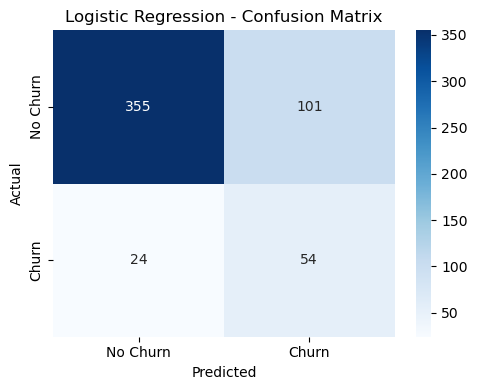

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

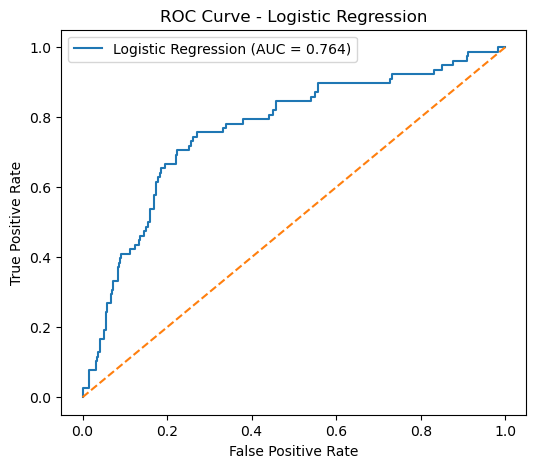

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

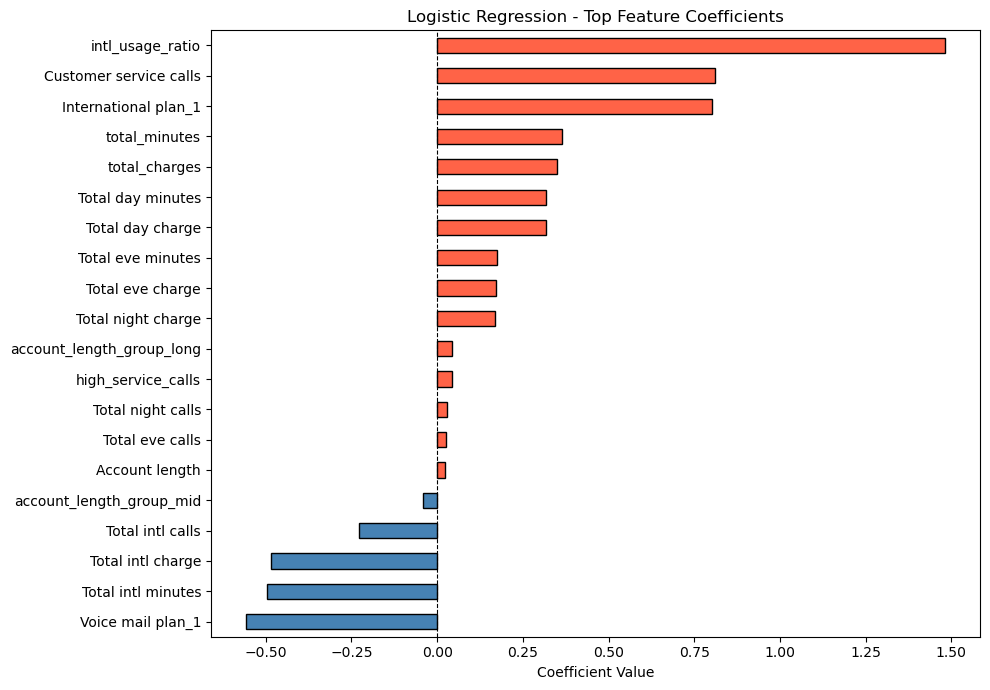


Top 10 Positive Coefficients (churn drivers):
intl_usage_ratio          1.4816
Customer service calls    0.8111
International plan_1      0.8019
total_minutes             0.3638
total_charges             0.3495
Total day minutes         0.3178
Total day charge          0.3168
Total eve minutes         0.1737
Total eve charge          0.1721
Total night charge        0.1688
dtype: float64

Top 10 Negative Coefficients (churn reducers):
Voice mail plan_1           -0.5583
Total intl minutes          -0.4972
Total intl charge           -0.4853
Total intl calls            -0.2285
account_length_group_mid    -0.0421
Account length               0.0229
Total eve calls              0.0261
Total night calls            0.0284
high_service_calls           0.0421
account_length_group_long    0.0434
dtype: float64


In [12]:
coef_series = pd.Series(
    log_reg.coef_[0],
    index=X_train.columns
).sort_values()

top_coefs = pd.concat([coef_series.head(10), coef_series.tail(10)])
colors = ["steelblue" if v < 0 else "tomato" for v in top_coefs.values]

top_coefs.plot(kind="barh", figsize=(10, 7), color=colors, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Logistic Regression - Top Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print("\nTop 10 Positive Coefficients (churn drivers):")
print(coef_series.tail(10).sort_values(ascending=False).round(4))
print("\nTop 10 Negative Coefficients (churn reducers):")
print(coef_series.head(10).round(4))